# Fresh Believability Analysis With Plots (Overall: All Participants)

This notebook runs a fresh analysis using all participants combined, from the datasets in the `Overall` folder.

Primary analysis dataset:
- `Cleaned.csv`

Design summary:
- Repeated-measures design
- Same participants rate multiple misinformation headlines
- Outcome: `believability_rating` (1 to 5)
- Within-person factors: `topic`, `condition`, `cue_type_final`
- N = 50 participants, no outliers removed


In [1]:
import warnings
from pathlib import Path
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from scipy.stats import ttest_rel, ttest_1samp
from statsmodels.stats.anova import AnovaRM
from statsmodels.stats.multitest import multipletests
from IPython.display import display
import statsmodels.formula.api as smf

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 50)
pd.set_option('display.width', 140)
sns.set_theme(style='whitegrid', context='talk')


In [ ]:
DATA_PATH = Path('Cleaned.csv')
LLM_PATH  = Path('LLM_Labels.csv')

# Load wide-format Stage 2-2 and LLM feature sheet
s22 = pd.read_csv(DATA_PATH)
llm = pd.read_csv(LLM_PATH).dropna(subset=['text'])

# Identify believability rating columns and meta columns
rating_cols = [c for c in s22.columns if 'Believability' in c]
meta_cols   = [c for c in s22.columns if c not in rating_cols]

# Melt wide -> long
melted = s22.melt(id_vars=meta_cols, value_vars=rating_cols,
                  var_name='column_header', value_name='believability_rating')
melted['text'] = melted['column_header'].str.split('\n').str[0].str.strip()

# Merge LLM features
df = melted.merge(llm[['text', 'topic', 'condition', 'cue_type_final']], on='text', how='left')

analysis_cols = [
    'Participation Id',
    'Age',
    'Gender',
    'Main Source of Information',
    'Education Level (Completed/Current)',
    'Employement',
    'believability_rating',
    'text',
    'topic',
    'condition',
    'cue_type_final',
]

analysis_df = df[analysis_cols].copy()
analysis_df = analysis_df.dropna(subset=['Participation Id', 'believability_rating', 'text', 'topic', 'condition', 'cue_type_final'])
analysis_df['Participation Id'] = analysis_df['Participation Id'].astype(int)
analysis_df['believability_rating'] = pd.to_numeric(analysis_df['believability_rating'], errors='coerce')
analysis_df['topic'] = pd.Categorical(analysis_df['topic'], categories=['health', 'technology'], ordered=True)
analysis_df['condition'] = pd.Categorical(analysis_df['condition'], categories=['latent', 'recent', 'new'], ordered=True)
analysis_df['cue_type_final'] = pd.Categorical(analysis_df['cue_type_final'], categories=['central', 'neutral', 'peripheral'], ordered=True)
analysis_df.shape


(1800, 11)

In [3]:
print('Rows:', len(analysis_df))
print('Participants:', analysis_df['Participation Id'].nunique())
print('Headlines:', analysis_df['text'].nunique())
print('\nLevels')
print('Topic:', analysis_df['topic'].value_counts().sort_index().to_dict())
print('Condition:', analysis_df['condition'].value_counts().sort_index().to_dict())
print('Cue:', analysis_df['cue_type_final'].value_counts().sort_index().to_dict())
analysis_df.head()


Rows: 1800
Participants: 50
Headlines: 36

Levels
Topic: {'health': 900, 'technology': 900}
Condition: {'latent': 600, 'recent': 600, 'new': 600}
Cue: {'central': 600, 'neutral': 600, 'peripheral': 600}


,Participation Id,Age,Gender,Main Source of Information,Education Level (Completed/Current),Employement,believability_rating,text,topic,condition,cue_type_final
0,28,20,Female,"Social Media Apps (Instagram, Twitter, etc)",Bachelor’s degree,Student,3,Soaking your feet in warm mustard oil pulls a ...,health,latent,central
1,36,20,Female,"Social Media Apps (Instagram, Twitter, etc)",Bachelor’s degree,Student,3,Soaking your feet in warm mustard oil pulls a ...,health,latent,central
2,32,20,Female,"Social Media Apps (Instagram, Twitter, etc)",Bachelor’s degree,Student,2,Soaking your feet in warm mustard oil pulls a ...,health,latent,central
3,35,20,Female,"Social Media Apps (Instagram, Twitter, etc)",Bachelor’s degree,Student,2,Soaking your feet in warm mustard oil pulls a ...,health,latent,central
4,38,20,Male,Word of Mouth,Bachelor’s degree,Student,4,Soaking your feet in warm mustard oil pulls a ...,health,latent,central


## Helper Functions

In [4]:
def format_p(p):
    return '< .001' if p < 0.001 else f'= {p:.3f}'


def stars(p):
    if p < 0.001:
        return '***'
    if p < 0.01:
        return '**'
    if p < 0.05:
        return '*'
    return 'ns'


def paired_dz(x, y):
    diff = np.asarray(x) - np.asarray(y)
    return diff.mean() / diff.std(ddof=1)


def partial_eta_squared(F_value, df_num, df_den):
    return (F_value * df_num) / ((F_value * df_num) + df_den)


def participant_cell_means(data, within_factors):
    grouped = (
        data.groupby(['Participation Id'] + within_factors, observed=False)['believability_rating']
        .mean()
        .reset_index()
    )
    grouped = grouped.rename(columns={'Participation Id': 'participant_id', 'believability_rating': 'mean_rating'})
    return grouped


def rm_anova_table(data, within_factors):
    rm_df = participant_cell_means(data, within_factors)
    fit = AnovaRM(rm_df, depvar='mean_rating', subject='participant_id', within=within_factors).fit()
    table = fit.anova_table.reset_index().rename(columns={'index': 'effect'})
    table['partial_eta_sq'] = table.apply(lambda row: partial_eta_squared(row['F Value'], row['Num DF'], row['Den DF']), axis=1)
    return fit, table


def paired_posthoc_from_pivot(pivot_df, pairs, correction='bonferroni'):
    results = []
    raw_pvals = []
    for left, right in pairs:
        t_stat, p_val = ttest_rel(pivot_df[left], pivot_df[right])
        results.append({
            'comparison': f'{left} vs {right}',
            'mean_left': pivot_df[left].mean(),
            'mean_right': pivot_df[right].mean(),
            't': t_stat,
            'p_raw': p_val,
            'cohens_dz': paired_dz(pivot_df[left], pivot_df[right]),
        })
        raw_pvals.append(p_val)
    reject, p_adj, _, _ = multipletests(raw_pvals, method=correction)
    for row, reject_flag, adjusted in zip(results, reject, p_adj):
        row['p_adj'] = adjusted
        row['significant'] = bool(reject_flag)
    return pd.DataFrame(results)


def iqr_outliers(series):
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    outliers = series[(series < lower) | (series > upper)]
    return lower, upper, outliers


def mean_sem_summary(data, factors):
    cells = participant_cell_means(data, factors)
    summary = cells.groupby(factors, observed=False)['mean_rating'].agg(mean='mean', sem='sem').reset_index()
    return cells, summary


def add_sig_bracket(ax, x1, x2, y, text, h=0.05, lw=1.5, fontsize=12):
    ax.plot([x1, x1, x2, x2], [y, y + h, y + h, y], color='black', lw=lw, clip_on=False)
    ax.text((x1 + x2) / 2, y + h, text, ha='center', va='bottom', fontsize=fontsize)


def add_note_box(ax, text, loc=(0.02, 0.98), fontsize=11):
    ax.text(loc[0], loc[1], text, transform=ax.transAxes, ha='left', va='top', fontsize=fontsize,
            bbox=dict(boxstyle='round,pad=0.35', facecolor='white', edgecolor='black', alpha=0.9))


def effect_note(table, effect):
    row = table.loc[table['effect'] == effect].iloc[0]
    return (
        f"{effect}\n"
        f"F({int(row['Num DF'])}, {int(row['Den DF'])}) = {row['F Value']:.2f}, "
        f"p {format_p(row['Pr > F'])}, eta_p^2 = {row['partial_eta_sq']:.3f}"
    )


## Outlier Check & Removal

In [5]:
participant_mean_series = analysis_df.groupby('Participation Id')['believability_rating'].mean()
headline_mean_series = analysis_df.groupby('text')['believability_rating'].mean()
p_lower, p_upper, participant_outliers = iqr_outliers(participant_mean_series)
h_lower, h_upper, headline_outliers = iqr_outliers(headline_mean_series)
print('Participant mean bounds:', round(p_lower, 4), 'to', round(p_upper, 4))
print('Participant mean outliers:', participant_outliers.to_dict() if len(participant_outliers) else 'None')
print()
print('Headline mean bounds:', round(h_lower, 4), 'to', round(h_upper, 4))
print('Headline mean outliers:', headline_outliers.to_dict() if len(headline_outliers) else 'None')


Participant mean bounds: 1.2813 to 4.6979
Participant mean outliers: None

Headline mean bounds: 0.9725 to 4.8725
Headline mean outliers: None


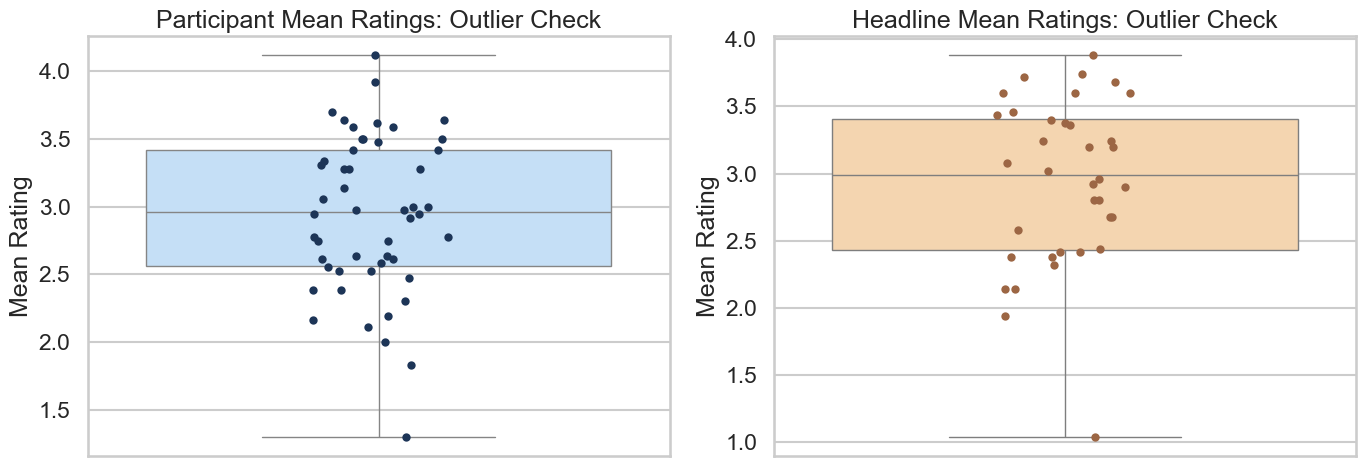

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(y=participant_mean_series.values, color='#bde0fe', ax=axes[0])
sns.stripplot(y=participant_mean_series.values, color='#1d3557', size=6, jitter=0.12, ax=axes[0])
axes[0].set_title('Participant Mean Ratings: Outlier Check')
axes[0].set_ylabel('Mean Rating')
axes[0].set_xlabel('')

sns.boxplot(y=headline_mean_series.values, color='#ffd6a5', ax=axes[1])
sns.stripplot(y=headline_mean_series.values, color='#9c6644', size=6, jitter=0.12, ax=axes[1])
axes[1].set_title('Headline Mean Ratings: Outlier Check')
axes[1].set_ylabel('Mean Rating')
axes[1].set_xlabel('')
plt.tight_layout()
plt.show()


In [7]:
# Remove outlier participants before all subsequent analyses
if len(participant_outliers) > 0:
    outlier_ids = participant_outliers.index.tolist()
    print(f'Removing {len(outlier_ids)} outlier participant(s): {outlier_ids}')
    analysis_df = analysis_df[~analysis_df['Participation Id'].isin(outlier_ids)].copy()
    analysis_df['topic'] = pd.Categorical(analysis_df['topic'], categories=['health', 'technology'], ordered=True)
    analysis_df['condition'] = pd.Categorical(analysis_df['condition'], categories=['latent', 'recent', 'new'], ordered=True)
    analysis_df['cue_type_final'] = pd.Categorical(analysis_df['cue_type_final'], categories=['central', 'neutral', 'peripheral'], ordered=True)
    print(f'Remaining participants: {analysis_df["Participation Id"].nunique()}')
else:
    print('No outlier participants detected. analysis_df unchanged.')


No outlier participants detected. analysis_df unchanged.


## Descriptive Statistics

In [8]:
overall_summary = {
    'n_participants': analysis_df['Participation Id'].nunique(),
    'n_headlines': analysis_df['text'].nunique(),
    'n_ratings': len(analysis_df),
    'mean_rating': analysis_df['believability_rating'].mean(),
    'sd_rating': analysis_df['believability_rating'].std(),
    'median_rating': analysis_df['believability_rating'].median(),
    'prop_not_believable_1_2': (analysis_df['believability_rating'] <= 2).mean(),
    'prop_neutral_3': (analysis_df['believability_rating'] == 3).mean(),
    'prop_believable_4_5': (analysis_df['believability_rating'] >= 4).mean(),
}
pd.Series(overall_summary).round(4)


n_participants               50.0000
n_headlines                  36.0000
n_ratings                  1800.0000
mean_rating                   2.9383
sd_rating                     1.3552
median_rating                 3.0000
prop_not_believable_1_2       0.3900
prop_neutral_3                0.2256
prop_believable_4_5           0.3844
dtype: float64

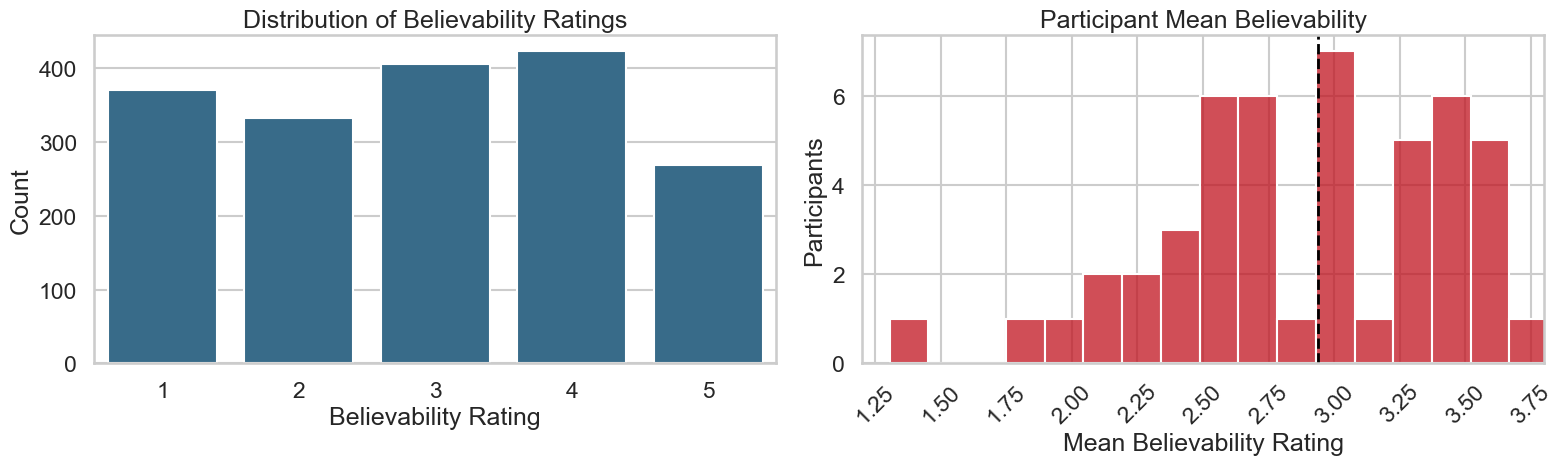

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.countplot(data=analysis_df, x='believability_rating', color='#2a6f97', ax=axes[0])
axes[0].set_title('Distribution of Believability Ratings')
axes[0].set_xlabel('Believability Rating')
axes[0].set_ylabel('Count')

participant_means_hist = analysis_df.groupby('Participation Id')['believability_rating'].mean().reset_index()
sns.histplot(participant_means_hist['believability_rating'], binwidth=0.15, color='#c1121f', ax=axes[1])
axes[1].axvline(participant_means_hist['believability_rating'].mean(), color='black', linestyle='--', linewidth=2)
axes[1].set_title('Participant Mean Believability')
axes[1].set_xlabel('Mean Believability Rating')
axes[1].set_ylabel('Participants')
axes[1].set_xlim(1.2, 3.8)
axes[1].set_xticks(np.arange(1.25, 3.76, 0.25))
axes[1].tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()


## Question 1: Were People More Likely to Believe Misinformation or Not?

In [10]:
participant_means = analysis_df.groupby('Participation Id')['believability_rating'].mean()
t_stat, p_val = ttest_1samp(participant_means, popmean=3.0)
overall_test = pd.Series({
    'participant_mean_average': participant_means.mean(),
    'participant_mean_sd': participant_means.std(),
    't_statistic': t_stat,
    'p_value': p_val,
})
overall_test.round(4)

participant_mean_average    2.9383
participant_mean_sd         0.5804
t_statistic                -0.7512
p_value                     0.4561
dtype: float64

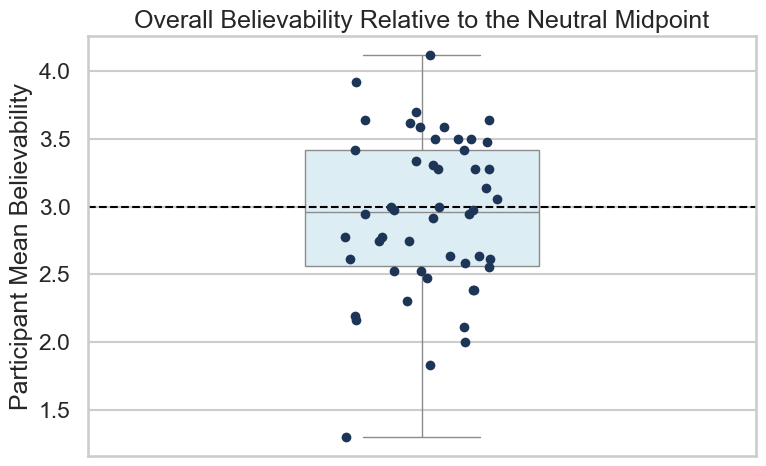

In [11]:
participant_mean_df = participant_means.reset_index(name='mean_rating')
fig, ax = plt.subplots(figsize=(8, 5))
sns.boxplot(data=participant_mean_df, y='mean_rating', color='#d8eff7', width=0.35, ax=ax)
sns.stripplot(data=participant_mean_df, y='mean_rating', color='#1d3557', size=7, jitter=0.12, ax=ax)
ax.axhline(3, color='black', linestyle='--', linewidth=1.5)
ax.set_title('Overall Believability Relative to the Neutral Midpoint')
ax.set_xlabel('')
ax.set_ylabel('Participant Mean Believability')
plt.tight_layout()
plt.show()

**Figure Note: Overall Believability**

**Method**
This figure uses each participant's mean believability rating across all misinformation items. A one-sample t-test compares those participant means against the neutral midpoint of 3. This approach accounts for stable individual differences in skepticism or credulity because the unit of analysis is the participant mean. No outliers were detected or removed.

**Null Hypothesis**
The mean participant believability rating is equal to 3, the neutral midpoint.

**Interpretation**
The mean participant believability score was 2.94 (SD = 0.58), which was not significantly different from the neutral midpoint, `t(49) = -0.75, p = 0.456`. This indicates that participants were, on average, neither systematically credulous nor skeptical of the misinformation stimuli. The overall sample showed no reliable credulity or skepticism bias.

**Exact Significance Values**

| Test | Statistic | Exact p-value | Result |
|---|---:|---:|---|
| One-sample t-test vs midpoint 3 | t(49) = -0.75 | p = 0.456 | Not significant |

**About The Box Plot**
The line inside the box is the median. The bottom and top of the box are the 25th and 75th percentiles. The whiskers show the range of non-outlier values under the 1.5 x IQR rule.


## Question 2: Do Cue Types Differ in Believability?

In [12]:
cue_fit, cue_table = rm_anova_table(analysis_df, ['cue_type_final'])
cue_means = analysis_df.groupby('cue_type_final', observed=False)['believability_rating'].mean().reset_index()
display(cue_means.round(4))
display(cue_table.round(4))


,cue_type_final,believability_rating
0,central,3.0417
1,neutral,3.0067
2,peripheral,2.7667


,effect,F Value,Num DF,Den DF,Pr > F,partial_eta_sq
0,cue_type_final,6.7035,2.0,98.0,0.0019,0.1203


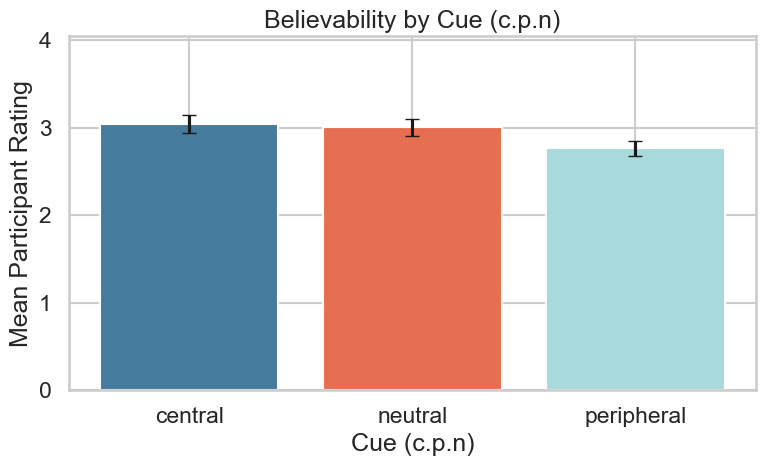

In [13]:
cue_cells, cue_summary = mean_sem_summary(analysis_df, ['cue_type_final'])
cue_order = list(analysis_df['cue_type_final'].cat.categories)
cue_positions = np.arange(len(cue_order))
fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(cue_positions, cue_summary['mean'], yerr=cue_summary['sem'], capsize=5, color=['#457b9d', '#e76f51', '#a8dadc'])
ax.set_xticks(cue_positions)
ax.set_xticklabels(cue_order)
ax.set_ylim(0, max(cue_summary['mean'] + cue_summary['sem']) + 0.9)
ax.set_title('Believability by Cue (c.p.n)')
ax.set_xlabel('Cue (c.p.n)')
ax.set_ylabel('Mean Participant Rating')
plt.tight_layout()
plt.show()


**Figure Note: Cue (c.p.n)**

**Method**
This figure uses a one-factor repeated-measures ANOVA comparing mean believability across cue type (central, peripheral, and neutral), followed by Bonferroni-corrected paired t-tests for all three pairwise comparisons. Error bars represent the standard error of participant-level means.

**Null Hypothesis**
Mean believability does not differ across cue type levels.

**Interpretation**
The main effect of cue type was significant, `F(2, 98) = 6.70, p = .002, η²p = 0.120`. Post-hoc Bonferroni-corrected tests showed that peripheral cues (M = 2.77) were rated significantly less believable than both central (M = 3.04, p = .018) and neutral (M = 3.01, p = .013) cues. Central and neutral cues did not differ significantly (p = 1.000).

**ANOVA**

| Effect | F | df | p | η²p |
|---|---|---|---|---|
| Cue type | F(2, 98) = 6.70 | 2, 98 | = .002 | 0.120 |

**Post-hoc pairwise comparisons (Bonferroni-corrected)**

| Comparison | Mean (left) | Mean (right) | t(49) | p (adjusted) | Significant |
|---|---|---|---|---|---|
| central vs neutral | 3.042 | 3.007 | 0.53 | p = 1.000 | No |
| central vs peripheral | 3.042 | 2.767 | 2.88 | p = .018 | Yes |
| neutral vs peripheral | 3.007 | 2.767 | 2.98 | p = .013 | Yes |


## Question 3: Do Conditions Differ in Believability?

In [14]:
condition_fit, condition_table = rm_anova_table(analysis_df, ['condition'])
condition_means = analysis_df.groupby('condition', observed=False)['believability_rating'].mean().reset_index()
condition_cells = participant_cell_means(analysis_df, ['condition'])
condition_pivot = condition_cells.pivot(index='participant_id', columns='condition', values='mean_rating')
condition_pairs = [('latent', 'recent'), ('latent', 'new'), ('recent', 'new')]
condition_posthoc = paired_posthoc_from_pivot(condition_pivot, condition_pairs)
display(condition_means.round(4))
display(condition_table.round(4))
display(condition_posthoc.round(4))


,condition,believability_rating
0,latent,3.0350
1,recent,3.1017
2,new,2.6783


,effect,F Value,Num DF,Den DF,Pr > F,partial_eta_sq
0,condition,28.312,2.0,98.0,0.0,0.3662


,comparison,mean_left,mean_right,t,p_raw,cohens_dz,p_adj,significant
0,latent vs recent,3.0350,3.1017,-1.1983,0.2366,-0.1695,0.7097,False
1,latent vs new,3.0350,2.6783,5.6985,0.0000,0.8059,0.0000,True
2,recent vs new,3.1017,2.6783,6.7210,0.0000,0.9505,0.0000,True


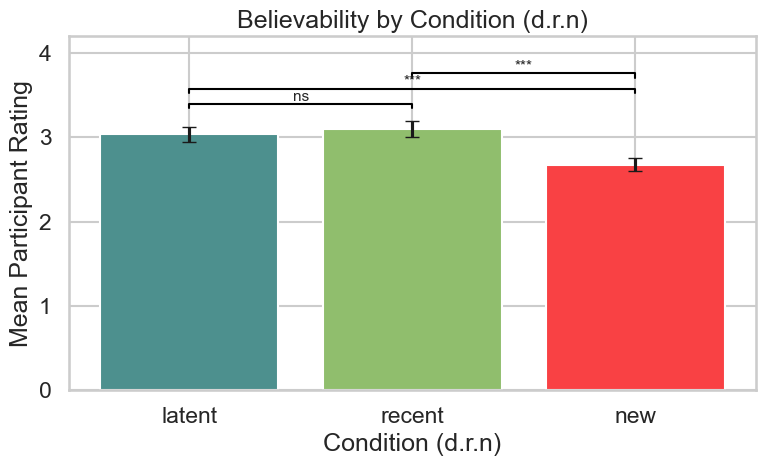

In [15]:
condition_order = list(analysis_df['condition'].cat.categories)
condition_positions = np.arange(len(condition_order))
_, condition_summary = mean_sem_summary(analysis_df, ['condition'])
fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(condition_positions, condition_summary['mean'], yerr=condition_summary['sem'], capsize=5, color=['#4d908e', '#90be6d', '#f94144'])
ax.set_xticks(condition_positions)
ax.set_xticklabels(condition_order)
ax.set_ylim(0, max(condition_summary['mean'] + condition_summary['sem']) + 1.0)
ax.set_title('Believability by Condition (d.r.n)')
ax.set_xlabel('Condition (d.r.n)')
ax.set_ylabel('Mean Participant Rating')
y_start = max(condition_summary['mean'] + condition_summary['sem']) + 0.15
for offset, row in enumerate(condition_posthoc.itertuples(index=False)):
    left, right = row.comparison.split(' vs ')
    x1 = condition_order.index(left)
    x2 = condition_order.index(right)
    add_sig_bracket(ax, x1, x2, y_start + offset * 0.18, stars(row.p_adj), h=0.05, fontsize=11)
plt.tight_layout()
plt.show()


**Figure Note: Condition (latent/recent/new)**

**Method**
This figure uses a repeated-measures ANOVA comparing mean believability across condition (latent, recent, and new), followed by Bonferroni-corrected paired t-tests. Error bars represent the standard error of participant-level means.

**Null Hypothesis**
Mean believability does not differ across condition levels.

**Interpretation**
The main effect of condition was highly significant, `F(2, 98) = 28.31, p < .001, η²p = 0.366`. Post-hoc tests showed that the new condition was significantly less believable than both latent and recent, while latent and recent did not differ. Newly introduced misinformation was judged as less credible, whereas latent and recent framings produced similarly higher credibility.

**ANOVA**

| Effect | F | df | p | η²p |
|---|---|---|---|---|
| Condition | F(2, 98) = 28.31 | 2, 98 | < .001 | 0.366 |

**Post-hoc pairwise comparisons (Bonferroni-corrected)**

| Comparison | Mean (left) | Mean (right) | t(49) | p (adjusted) | Significant |
|---|---|---|---|---|---|
| latent vs recent | 3.035 | 3.102 | -1.20 | p = 0.710 | No |
| latent vs new | 3.035 | 2.678 | 5.70 | p < .001 | Yes |
| recent vs new | 3.102 | 2.678 | 6.72 | p < .001 | Yes |


## Question 4: Do Topics Differ in Believability?

In [16]:
topic_cells = participant_cell_means(analysis_df, ['topic'])
topic_pivot = topic_cells.pivot(index='participant_id', columns='topic', values='mean_rating')
topic_t, topic_p = ttest_rel(topic_pivot['health'], topic_pivot['technology'])
topic_results = pd.Series({
    'health_mean': topic_pivot['health'].mean(),
    'technology_mean': topic_pivot['technology'].mean(),
    't_statistic': topic_t,
    'p_value': topic_p,
    'cohens_dz': paired_dz(topic_pivot['health'], topic_pivot['technology']),
})
topic_results.round(4)


health_mean        3.0211
technology_mean    2.8556
t_statistic        2.2065
p_value            0.0321
cohens_dz          0.3120
dtype: float64

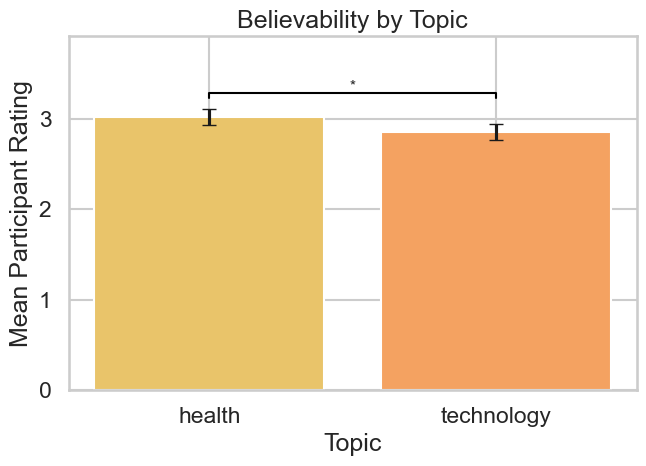

In [17]:
topic_order = list(analysis_df['topic'].cat.categories)
topic_positions = np.arange(len(topic_order))
_, topic_summary = mean_sem_summary(analysis_df, ['topic'])
fig, ax = plt.subplots(figsize=(7, 5))
ax.bar(topic_positions, topic_summary['mean'], yerr=topic_summary['sem'], capsize=5, color=['#e9c46a', '#f4a261'])
ax.set_xticks(topic_positions)
ax.set_xticklabels(topic_order)
ax.set_ylim(0, max(topic_summary['mean'] + topic_summary['sem']) + 0.8)
ax.set_title('Believability by Topic')
ax.set_xlabel('Topic')
ax.set_ylabel('Mean Participant Rating')
y_topic = max(topic_summary['mean'] + topic_summary['sem']) + 0.12
add_sig_bracket(ax, 0, 1, y_topic, stars(topic_p), h=0.05, fontsize=11)
plt.tight_layout()
plt.show()


**Figure Note: Topic**

**Method**
This figure uses a paired-samples t-test comparing participants' mean believability for health versus technology misinformation. Error bars represent the standard error of participant-level means.

**Null Hypothesis**
Mean believability does not differ between health and technology misinformation.

**Interpretation**
The topic effect was significant, `t(49) = 2.21, p = 0.032, d_z = 0.312`. Health misinformation (M = 3.021) was rated as more believable than technology misinformation (M = 2.856). This indicates a domain-specific credibility effect: the health domain elicited greater perceived plausibility than the technology domain.

**Exact Significance Values**

| Test | Statistic | Exact p-value | Result |
|---|---:|---:|---|
| Paired-samples t-test for topic | t(49) = 2.21 | p = 0.032 | Significant |


## Question 5: Two-Way Interactions

In [18]:
cue_condition_fit, cue_condition_table = rm_anova_table(analysis_df, ['cue_type_final', 'condition'])
topic_condition_fit, topic_condition_table = rm_anova_table(analysis_df, ['topic', 'condition'])
topic_cue_fit, topic_cue_table = rm_anova_table(analysis_df, ['topic', 'cue_type_final'])
display(cue_condition_table.round(4))
display(topic_condition_table.round(4))
display(topic_cue_table.round(4))


,effect,F Value,Num DF,Den DF,Pr > F,partial_eta_sq
0,cue_type_final,6.7035,2.0,98.0,0.0019,0.1203
1,condition,28.3120,2.0,98.0,0.0000,0.3662
2,cue_type_final:condition,18.5065,4.0,196.0,0.0000,0.2741


,effect,F Value,Num DF,Den DF,Pr > F,partial_eta_sq
0,topic,4.8684,1.0,49.0,0.0321,0.0904
1,condition,28.3120,2.0,98.0,0.0000,0.3662
2,topic:condition,33.3279,2.0,98.0,0.0000,0.4048


,effect,F Value,Num DF,Den DF,Pr > F,partial_eta_sq
0,topic,4.8684,1.0,49.0,0.0321,0.0904
1,cue_type_final,6.7035,2.0,98.0,0.0019,0.1203
2,topic:cue_type_final,0.3654,2.0,98.0,0.6949,0.0074


In [19]:
topic_condition_cells = participant_cell_means(analysis_df, ['topic', 'condition'])
topic_condition_pivot = topic_condition_cells.pivot(index='participant_id', columns=['topic', 'condition'], values='mean_rating')
topic_within_condition = []
for condition in analysis_df['condition'].cat.categories:
    left = topic_condition_pivot[('health', condition)]
    right = topic_condition_pivot[('technology', condition)]
    t_stat, p_raw = ttest_rel(left, right)
    topic_within_condition.append({
        'condition': condition,
        'health_mean': left.mean(),
        'technology_mean': right.mean(),
        't': t_stat,
        'p_raw': p_raw,
        'cohens_dz': paired_dz(left, right),
    })
topic_within_condition = pd.DataFrame(topic_within_condition)
topic_within_condition['p_adj'] = multipletests(topic_within_condition['p_raw'], method='bonferroni')[1]
topic_within_condition['significant'] = topic_within_condition['p_adj'] < 0.05
display(topic_within_condition.round(4))

condition_within_topic_rows = []
for topic in analysis_df['topic'].cat.categories:
    subset = topic_condition_pivot[topic]
    posthoc_df = paired_posthoc_from_pivot(subset, [('latent', 'recent'), ('latent', 'new'), ('recent', 'new')])
    posthoc_df.insert(0, 'topic', topic)
    condition_within_topic_rows.append(posthoc_df)
condition_within_topic = pd.concat(condition_within_topic_rows, ignore_index=True)
display(condition_within_topic.round(4))


,condition,health_mean,technology_mean,t,p_raw,cohens_dz,p_adj,significant
0,latent,2.9367,3.1333,-1.8294,0.0734,-0.2587,0.2203,False
1,recent,3.4267,2.7767,6.9454,0.0000,0.9822,0.0000,True
2,new,2.7000,2.6567,0.4845,0.6302,0.0685,1.0000,False


,topic,comparison,mean_left,mean_right,t,p_raw,cohens_dz,p_adj,significant
0,health,latent vs recent,2.9367,3.4267,-5.8405,0.0000,-0.8260,0.0000,True
1,health,latent vs new,2.9367,2.7000,3.5492,0.0009,0.5019,0.0026,True
2,health,recent vs new,3.4267,2.7000,9.7342,0.0000,1.3766,0.0000,True
3,technology,latent vs recent,3.1333,2.7767,4.8448,0.0000,0.6852,0.0000,True
4,technology,latent vs new,3.1333,2.6567,4.7720,0.0000,0.6749,0.0001,True
5,technology,recent vs new,2.7767,2.6567,1.4721,0.1474,0.2082,0.4422,False


In [20]:
cue_condition_cells = participant_cell_means(analysis_df, ['cue_type_final', 'condition'])
cue_condition_pivot = cue_condition_cells.pivot(index='participant_id', columns=['cue_type_final', 'condition'], values='mean_rating')
cue_within_condition_rows = []
for condition in analysis_df['condition'].cat.categories:
    subset = cue_condition_pivot.xs(condition, axis=1, level='condition')
    posthoc_df = paired_posthoc_from_pivot(subset, [('central', 'neutral'), ('central', 'peripheral'), ('neutral', 'peripheral')])
    posthoc_df.insert(0, 'condition', condition)
    cue_within_condition_rows.append(posthoc_df)
cue_within_condition = pd.concat(cue_within_condition_rows, ignore_index=True)
display(cue_within_condition.round(4))

condition_within_cue_rows = []
for cue in analysis_df['cue_type_final'].cat.categories:
    subset = cue_condition_pivot[cue]
    posthoc_df = paired_posthoc_from_pivot(subset, [('latent', 'recent'), ('latent', 'new'), ('recent', 'new')])
    posthoc_df.insert(0, 'cue_type_final', cue)
    condition_within_cue_rows.append(posthoc_df)
condition_within_cue = pd.concat(condition_within_cue_rows, ignore_index=True)
display(condition_within_cue.round(4))


,condition,comparison,mean_left,mean_right,t,p_raw,cohens_dz,p_adj,significant
0,latent,central vs neutral,2.980,2.950,0.2503,0.8034,0.0354,1.0000,False
1,latent,central vs peripheral,2.980,3.175,-1.2304,0.2244,-0.1740,0.6732,False
2,latent,neutral vs peripheral,2.950,3.175,-1.6196,0.1117,-0.2291,0.3352,False
3,recent,central vs neutral,3.415,2.965,5.3056,0.0000,0.7503,0.0000,True
4,recent,central vs peripheral,3.415,2.925,4.1073,0.0002,0.5809,0.0005,True
5,recent,neutral vs peripheral,2.965,2.925,0.3247,0.7468,0.0459,1.0000,False
6,new,central vs neutral,2.730,3.105,-3.3661,0.0015,-0.4760,0.0045,True
7,new,central vs peripheral,2.730,2.200,4.6499,0.0000,0.6576,0.0001,True
8,new,neutral vs peripheral,3.105,2.200,7.7995,0.0000,1.1030,0.0000,True


,cue_type_final,comparison,mean_left,mean_right,t,p_raw,cohens_dz,p_adj,significant
0,central,latent vs recent,2.980,3.415,-4.3521,0.0001,-0.6155,0.0002,True
1,central,latent vs new,2.980,2.730,2.6923,0.0097,0.3807,0.0291,True
2,central,recent vs new,3.415,2.730,8.4827,0.0000,1.1996,0.0000,True
3,neutral,latent vs recent,2.950,2.965,-0.1590,0.8743,-0.0225,1.0000,False
4,neutral,latent vs new,2.950,3.105,-1.1719,0.2469,-0.1657,0.7407,False
5,neutral,recent vs new,2.965,3.105,-1.2569,0.2147,-0.1778,0.6442,False
6,peripheral,latent vs recent,3.175,2.925,2.1222,0.0389,0.3001,0.1167,False
7,peripheral,latent vs new,3.175,2.200,7.8907,0.0000,1.1159,0.0000,True
8,peripheral,recent vs new,2.925,2.200,6.1402,0.0000,0.8684,0.0000,True


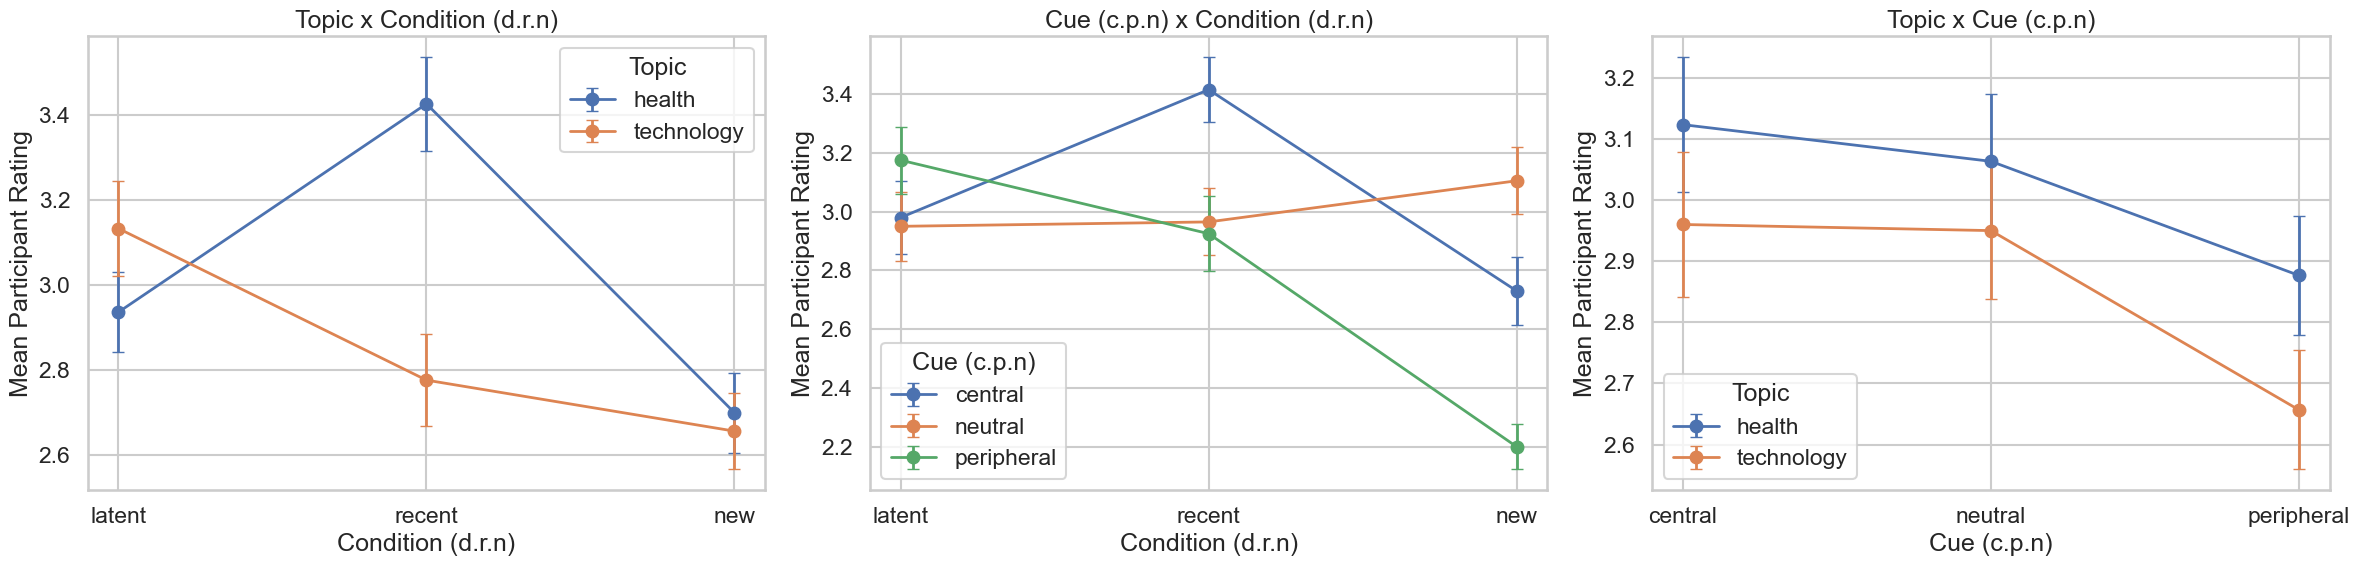

In [21]:
fig, axes = plt.subplots(1, 3, figsize=(24, 6))

_, topic_condition_summary = mean_sem_summary(analysis_df, ['topic', 'condition'])
for topic in topic_order:
    subset = topic_condition_summary[topic_condition_summary['topic'] == topic]
    axes[0].errorbar(condition_order, subset['mean'], yerr=subset['sem'], marker='o', linewidth=2, capsize=4, label=topic)
axes[0].set_title('Topic x Condition (d.r.n)')
axes[0].set_xlabel('Condition (d.r.n)')
axes[0].set_ylabel('Mean Participant Rating')
axes[0].legend(title='Topic')

_, cue_condition_summary = mean_sem_summary(analysis_df, ['cue_type_final', 'condition'])
for cue in cue_order:
    subset = cue_condition_summary[cue_condition_summary['cue_type_final'] == cue]
    axes[1].errorbar(condition_order, subset['mean'], yerr=subset['sem'], marker='o', linewidth=2, capsize=4, label=cue)
axes[1].set_title('Cue (c.p.n) x Condition (d.r.n)')
axes[1].set_xlabel('Condition (d.r.n)')
axes[1].set_ylabel('Mean Participant Rating')
axes[1].legend(title='Cue (c.p.n)')

_, topic_cue_summary = mean_sem_summary(analysis_df, ['topic', 'cue_type_final'])
for topic in topic_order:
    subset = topic_cue_summary[topic_cue_summary['topic'] == topic]
    axes[2].errorbar(cue_order, subset['mean'], yerr=subset['sem'], marker='o', linewidth=2, capsize=4, label=topic)
axes[2].set_title('Topic x Cue (c.p.n)')
axes[2].set_xlabel('Cue (c.p.n)')
axes[2].set_ylabel('Mean Participant Rating')
axes[2].legend(title='Topic')
plt.tight_layout()
plt.show()


**Figure Note: Two-Way Interactions**

**Method**
These panels use repeated-measures ANOVA to test whether the effect of one factor depends on another. Significant interactions are followed by Bonferroni-corrected simple-effects tests. Error bars represent the standard error of participant-level means.

**Null Hypotheses**
The effect of topic does not depend on condition. The effect of cue type does not depend on condition. The effect of topic does not depend on cue type.

**ANOVA summary**

| Interaction | F | df | p | η²p | Significant |
|---|---|---|---|---|---|
| Topic × Condition | F(2, 98) = 33.33 | 2, 98 | < .001 | 0.405 | Yes |
| Cue × Condition | F(4, 196) = 18.51 | 4, 196 | < .001 | 0.274 | Yes |
| Topic × Cue | F(2, 98) = 0.37 | 2, 98 | = .695 | 0.007 | No |

**Topic × Condition: topic simple effects within each condition (Bonferroni-corrected)**

| Condition | Health mean | Technology mean | t(49) | p (adjusted) | Significant |
|---|---|---|---|---|---|
| latent | 2.937 | 3.133 | -1.83 | p = 0.220 | No |
| recent | 3.427 | 2.777 | 6.95 | p < .001 | Yes |
| new | 2.700 | 2.657 | 0.48 | p = 1.000 | No |

**Cue × Condition: cue pairwise within each condition (Bonferroni-corrected)**

| Condition | Comparison | Mean (left) | Mean (right) | t(49) | p (adjusted) | Significant |
|---|---|---|---|---|---|---|
| latent | central vs neutral | 2.980 | 2.950 | 0.25 | p = 1.000 | No |
| latent | central vs peripheral | 2.980 | 3.175 | -1.23 | p = 0.673 | No |
| latent | neutral vs peripheral | 2.950 | 3.175 | -1.62 | p = 0.335 | No |
| recent | central vs neutral | 3.415 | 2.965 | 5.31 | p < .001 | Yes |
| recent | central vs peripheral | 3.415 | 2.925 | 4.11 | p < .001 | Yes |
| recent | neutral vs peripheral | 2.965 | 2.925 | 0.32 | p = 1.000 | No |
| new | central vs neutral | 2.730 | 3.105 | -3.37 | p = .005 | Yes |
| new | central vs peripheral | 2.730 | 2.200 | 4.65 | p < .001 | Yes |
| new | neutral vs peripheral | 3.105 | 2.200 | 7.80 | p < .001 | Yes |

**Interpretation**
For Topic × Condition, only the recent condition showed a significant topic difference: health misinformation (M = 3.43) was substantially more believable than technology misinformation (M = 2.78). Latent and new conditions showed no significant topic difference after correction.

For Cue × Condition, no cue differences emerged in the latent condition. In the recent condition, central cues were more believable than both neutral and peripheral. In the new condition, peripheral cues were the least believable: both central and neutral were rated significantly higher than peripheral. Topic × Cue was not significant.


## Question 6: Three-Way Interaction

In [22]:
three_way_fit, three_way_table = rm_anova_table(analysis_df, ['topic', 'cue_type_final', 'condition'])
three_way_table.round(4)


,effect,F Value,Num DF,Den DF,Pr > F,partial_eta_sq
0,topic,4.8684,1.0,49.0,0.0321,0.0904
1,cue_type_final,6.7035,2.0,98.0,0.0019,0.1203
2,condition,28.3120,2.0,98.0,0.0000,0.3662
3,topic:cue_type_final,0.3654,2.0,98.0,0.6949,0.0074
4,topic:condition,33.3279,2.0,98.0,0.0000,0.4048
5,cue_type_final:condition,18.5065,4.0,196.0,0.0000,0.2741
6,topic:cue_type_final:condition,8.6745,4.0,196.0,0.0000,0.1504


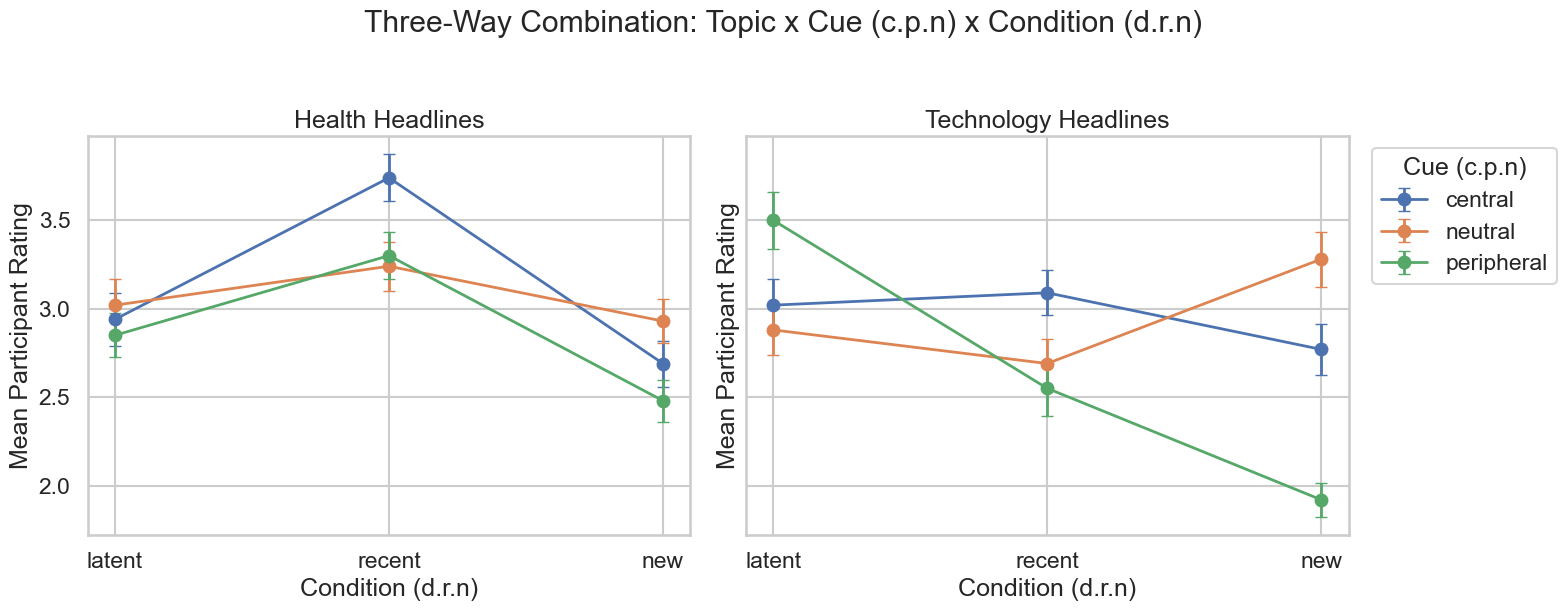

In [23]:
three_way_cells, three_way_summary = mean_sem_summary(analysis_df, ['topic', 'cue_type_final', 'condition'])
fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)
for ax, topic in zip(axes, topic_order):
    topic_subset = three_way_summary[three_way_summary['topic'] == topic]
    for cue in cue_order:
        cue_subset = topic_subset[topic_subset['cue_type_final'] == cue]
        ax.errorbar(condition_order, cue_subset['mean'], yerr=cue_subset['sem'], marker='o', linewidth=2, capsize=4, label=cue)
    ax.set_title(f'{topic.title()} Headlines')
    ax.set_xlabel('Condition (d.r.n)')
    ax.set_ylabel('Mean Participant Rating')
axes[1].legend(title='Cue (c.p.n)', bbox_to_anchor=(1.02, 1), loc='upper left')
fig.suptitle('Three-Way Combination: Topic x Cue (c.p.n) x Condition (d.r.n)', y=1.03)
plt.tight_layout()
plt.show()


**Figure Note: Three-Way Interaction**

**Method**
This figure uses a three-factor repeated-measures ANOVA testing Topic × Cue × Condition, followed by Bonferroni-corrected cue pairwise comparisons within each topic × condition cell. The two panels split the data by topic. Error bars represent the standard error of participant-level means.

**Null Hypothesis**
The Topic × Cue × Condition interaction is equal to zero.

**ANOVA**

| Effect | F | df | p | η²p |
|---|---|---|---|---|
| Topic × Cue × Condition | F(4, 196) = 8.67 | 4, 196 | < .001 | 0.150 |

**Post-hoc: cue pairwise within each topic × condition cell (Bonferroni-corrected)**

| Topic | Condition | Comparison | Mean (left) | Mean (right) | t(49) | p (adjusted) | Significant |
|---|---|---|---|---|---|---|---|
| health | latent | central vs neutral | 2.940 | 3.020 | -0.48 | p = 1.000 | No |
| health | latent | central vs peripheral | 2.940 | 2.850 | 0.46 | p = 1.000 | No |
| health | latent | neutral vs peripheral | 3.020 | 2.850 | 0.90 | p = 1.000 | No |
| health | recent | central vs neutral | 3.740 | 3.240 | 4.72 | p < .001 | Yes |
| health | recent | central vs peripheral | 3.740 | 3.300 | 3.29 | p = .006 | Yes |
| health | recent | neutral vs peripheral | 3.240 | 3.300 | -0.40 | p = 1.000 | No |
| health | new | central vs neutral | 2.690 | 2.930 | -1.68 | p = 0.299 | No |
| health | new | central vs peripheral | 2.690 | 2.480 | 1.42 | p = 0.485 | No |
| health | new | neutral vs peripheral | 2.930 | 2.480 | 3.30 | p = .006 | Yes |
| technology | latent | central vs neutral | 3.020 | 2.880 | 0.85 | p = 1.000 | No |
| technology | latent | central vs peripheral | 3.020 | 3.500 | -2.43 | p = .056 | No |
| technology | latent | neutral vs peripheral | 2.880 | 3.500 | -3.70 | p = .002 | Yes |
| technology | recent | central vs neutral | 3.090 | 2.690 | 2.92 | p = .016 | Yes |
| technology | recent | central vs peripheral | 3.090 | 2.550 | 3.28 | p = .006 | Yes |
| technology | recent | neutral vs peripheral | 2.690 | 2.550 | 0.83 | p = 1.000 | No |
| technology | new | central vs neutral | 2.770 | 3.280 | -2.78 | p = .023 | Yes |
| technology | new | central vs peripheral | 2.770 | 1.920 | 5.08 | p < .001 | Yes |
| technology | new | neutral vs peripheral | 3.280 | 1.920 | 8.25 | p < .001 | Yes |

**Interpretation**
The three-way interaction was significant, `F(4, 196) = 8.67, p < .001, η²p = 0.150`. The cue-by-condition pattern differed substantially between health and technology topics.

Within the health topic: no cue differences appeared in the latent condition. In the recent condition, central cues were more believable than neutral and peripheral. In the new condition, neutral cues were more believable than peripheral cues.

Within the technology topic: in the latent condition, peripheral cues (M = 3.50) were more believable than neutral cues (M = 2.88, p = .002). In the recent condition, central cues (M = 3.09) were more believable than neutral and peripheral. In the new condition, peripheral cues (M = 1.92) were the least believable of all three cue types, rated significantly lower than both central and neutral.

This pattern confirms that peripheral cues have opposite effects on technology misinformation depending on temporal framing: they inflate believability for latent claims but strongly deflate it for new claims.


## Question 7: Outliers

In [24]:
participant_mean_series = analysis_df.groupby('Participation Id')['believability_rating'].mean()
headline_mean_series = analysis_df.groupby('text')['believability_rating'].mean()
p_lower, p_upper, participant_outliers = iqr_outliers(participant_mean_series)
h_lower, h_upper, headline_outliers = iqr_outliers(headline_mean_series)
print('Participant mean bounds:', round(p_lower, 4), 'to', round(p_upper, 4))
print('Participant mean outliers:', participant_outliers.to_dict() if len(participant_outliers) else 'None')
print()
print('Headline mean bounds:', round(h_lower, 4), 'to', round(h_upper, 4))
print('Headline mean outliers:', headline_outliers.to_dict() if len(headline_outliers) else 'None')


Participant mean bounds: 1.2813 to 4.6979
Participant mean outliers: None

Headline mean bounds: 0.9725 to 4.8725
Headline mean outliers: None


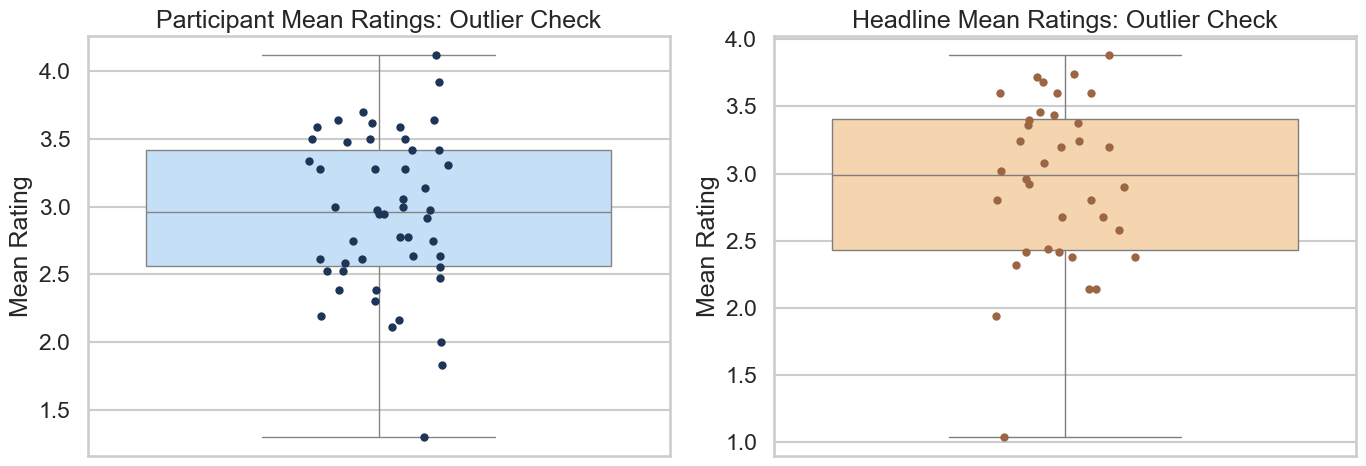

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(y=participant_mean_series.values, color='#bde0fe', ax=axes[0])
sns.stripplot(y=participant_mean_series.values, color='#1d3557', size=6, jitter=0.12, ax=axes[0])
axes[0].set_title('Participant Mean Ratings: Outlier Check')
axes[0].set_ylabel('Mean Rating')
axes[0].set_xlabel('')

sns.boxplot(y=headline_mean_series.values, color='#ffd6a5', ax=axes[1])
sns.stripplot(y=headline_mean_series.values, color='#9c6644', size=6, jitter=0.12, ax=axes[1])
axes[1].set_title('Headline Mean Ratings: Outlier Check')
axes[1].set_ylabel('Mean Rating')
axes[1].set_xlabel('')
plt.tight_layout()
plt.show()


**Figure Note: Outliers**

**Method**
These box plots check for unusually high or low mean ratings at two levels: participant-level means and headline-level means. The outlier rule is the interquartile range rule.

**Interpretation**
No participant-level or headline-level mean outliers were detected using the IQR rule (participant bounds: 1.28 to 4.70; headline bounds: 0.97 to 4.87). This suggests that the overall pattern of results is not being driven by a very small number of unusually skeptical, unusually credulous, or unusually extreme items.

**About The Box Plot**
The center line is the median. The box covers the 25th to 75th percentiles. The whiskers extend to the most extreme non-outlier values under the 1.5 x IQR rule.

| Outlier check | Result |
|---|---|
| Participant mean outliers | None |
| Headline mean outliers | None |


## Optional Robustness Check: Mixed-Effects Model

In [26]:
mixed_df = analysis_df.copy()
mixed_df['Participation Id'] = mixed_df['Participation Id'].astype('category')
mixed_df['text'] = mixed_df['text'].astype('category')
try:
    mixed_model = smf.mixedlm(
        'believability_rating ~ C(topic) * C(condition) * C(cue_type_final)',
        data=mixed_df,
        groups=mixed_df['Participation Id'],
        re_formula='1',
        vc_formula={'headline': '0 + C(text)'}
    )
    mixed_result = mixed_model.fit(reml=False, method='lbfgs', maxiter=200, disp=False)
    print(mixed_result.summary())
except Exception as exc:
    print('Mixed model did not finish cleanly:', exc)


                                         Mixed Linear Model Regression Results
Model:                              MixedLM                   Dependent Variable:                   believability_rating
No. Observations:                   1800                      Method:                               ML                  
No. Groups:                         50                        Scale:                                0.6188              
Min. group size:                    36                        Log-Likelihood:                       -2899.7780          
Max. group size:                    36                        Converged:                            Yes                 
Mean group size:                    36.0                                                                                
------------------------------------------------------------------------------------------------------------------------
                                                                          

**Mixed-Effects Model Note**

**Method**
The mixed-effects model is included as a robustness check beyond repeated-measures ANOVA. It predicts trial-level believability ratings from Topic, Cue type, Condition, and all interactions, while modeling participant-level and headline-level variability. Participant is treated as a random intercept and headline text is also modeled as a random intercept. The model was fit on N = 1,800 observations across 50 participants.

**Null Hypotheses**
Each fixed-effect coefficient is equal to zero after controlling for participant-level and headline-level random variation.

**Results**
The mixed model converged successfully. The random-effects section shows meaningful variance both across participants (Group Var = 0.292) and across headlines (Headline Var = 0.764), supporting the use of a multilevel approach.

The main fixed-effect findings were:
- `Condition (recent)` was significantly higher than the reference level (latent), `z = 4.81, p < .001`.
- `Topic × Condition (recent)` was significant, `z = -3.10, p = .002`.
- `Condition (recent) × Cue (neutral)` was significant, `z = -2.47, p = .014`.
- `Topic (technology) × Cue (peripheral)` was significant, `z = 2.42, p = .015`.
- `Topic (technology) × Condition (recent) × Cue (peripheral)` was significant, `z = -2.01, p = .044`.
- `Topic (technology) × Condition (new) × Cue (peripheral)` was significant, `z = -3.64, p < .001`.

The following were not significant in the mixed model:
- the main effect of topic,
- the main effect of cue (neutral or peripheral),
- the main effect of condition (new),
- most Topic × Cue and Topic × Condition (new) terms.

**Interpretation**
The mixed model broadly supports the repeated-measures findings: condition is the most reliable driver of believability, and the effect of cue type depends on condition and topic. Both participants and headlines contribute meaningful variance. The significant three-way terms are consistent with the ANOVA result that peripheral cues behave differently for technology misinformation depending on temporal framing.

**How To Read Differences Between ANOVA And Mixed Model**
ANOVA summarizes participant means within cells, whereas the mixed model keeps the item-level structure and explicitly models random variation across people and headlines. If one effect is significant in ANOVA but not in the mixed model, that usually means the effect becomes less stable once item-level variability is controlled.
